Subsurface Characterization Complete:
Identified Fundamental Resonance Frequency (f0): 2.35 Hz
Peak H/V Amplitude Ratio: 88.98


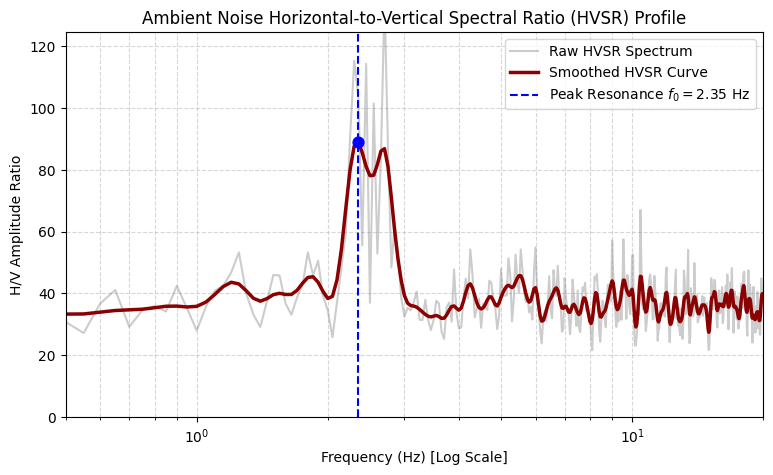

HVSR plot successfully saved to '../images/step6_hvsr_profiling.png'


In [1]:
import os
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt


os.makedirs('../images', exist_ok=True)     # Ensures output directories exist


#1 Generating Synthetic 3-Component Ambient Noise Data

np.random.seed(42)

sampling_rate = 100.0  # Hz
duration = 300.0       # 5 minutes of continuous recording
num_samples = int(sampling_rate * duration)
time = np.linspace(0, duration, num_samples)

# Simulating background urban white noise
noise_v = np.random.normal(0, 0.2, num_samples)  # Vertical
noise_e = np.random.normal(0, 0.2, num_samples)  # East-West
noise_n = np.random.normal(0, 0.2, num_samples)  # North-South

# Injecting site resonance around f0 = 2.5 Hz (typical soft soil layer over bedrock)
res_freq = 2.5  # Hz
resonance_signal = 0.8 * np.sin(2 * np.pi * res_freq * time) * np.exp(-((time % 10 - 5)**2) / 4)

# Horizontal channels experience strong resonance amplification due to shear waves
data_v = noise_v + 0.2 * resonance_signal
data_e = noise_e + 1.2 * resonance_signal
data_n = noise_n + 1.1 * resonance_signal


#2 Computingf Power Spectral Density (PSD) using Welch's Method

nperseg = int(sampling_rate * 20)  # 20-second windows for smooth averaging

freqs, psd_v = signal.welch(data_v, fs=sampling_rate, nperseg=nperseg)
_, freqs_e = signal.welch(data_e, fs=sampling_rate, nperseg=nperseg)[1], None
_, psd_e = signal.welch(data_e, fs=sampling_rate, nperseg=nperseg)
_, psd_n = signal.welch(data_n, fs=sampling_rate, nperseg=nperseg)

# Calculating combined horizontal amplitude: H = sqrt(E^2 + N^2)
psd_h = np.sqrt((psd_e + psd_n) / 2.0)

# Calculating H/V Ratio
hvsr_ratio = psd_h / (psd_v + 1e-8)  # Adding small epsilon to avoid division by zero

# Smooth HVSR curve using a moving average Gaussian filter
window_len = 11
kernel = np.exp(-np.linspace(-2, 2, window_len)**2)
kernel /= kernel.sum()
hvsr_smoothed = np.convolve(hvsr_ratio, kernel, mode='same')

# Identifying fundamental site resonance frequency (f0)
freq_mask = (freqs >= 0.5) & (freqs <= 10.0)
valid_freqs = freqs[freq_mask]
valid_hvsr = hvsr_smoothed[freq_mask]

f0_idx = np.argmax(valid_hvsr)
f0 = valid_freqs[f0_idx]
peak_amplitude = valid_hvsr[f0_idx]

print(f"Subsurface Characterization Complete:")
print(f"Identified Fundamental Resonance Frequency (f0): {f0:.2f} Hz")
print(f"Peak H/V Amplitude Ratio: {peak_amplitude:.2f}")


#3 Plotting and Saving Publication-Quality HVSR Profile

plt.figure(figsize=(9, 5))

# Plot raw vs smoothed HVSR
plt.plot(freqs, hvsr_ratio, color='gray', alpha=0.4, label='Raw HVSR Spectrum')
plt.plot(freqs, hvsr_smoothed, color='darkred', linewidth=2.5, label='Smoothed HVSR Curve')

# Highlight peak f0
plt.axvline(x=f0, color='blue', linestyle='--', linewidth=1.5, label=f'Peak Resonance $f_0 = {f0:.2f}$ Hz')
plt.scatter([f0], [peak_amplitude], color='blue', zorder=5, s=60)

plt.xscale('log')
plt.xlim(0.5, 20.0)
plt.ylim(0, max(hvsr_smoothed[freq_mask]) * 1.4)

plt.title('Ambient Noise Horizontal-to-Vertical Spectral Ratio (HVSR) Profile', fontsize=12)
plt.xlabel('Frequency (Hz) [Log Scale]', fontsize=10)
plt.ylabel('H/V Amplitude Ratio', fontsize=10)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

output_plot_path = '../images/step6_hvsr_profiling.png'
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"HVSR plot successfully saved to '{output_plot_path}'")